# Import modules

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import seaborn as sns
import warnings
import cmocean
import pyproj
warnings.filterwarnings('ignore')

%matplotlib inline

# Load data

In [3]:
grid = Grid.from_raster('../data/dem.tif')
dem = grid.read_raster('../data/dem.tif')
# We initialize flow direction to help define the initial grid viewfinder
fdir_raw = grid.read_ascii('../data/dir.asc')

# Clip to a smaller grid

In [4]:
# N NE E SE S SW W NW
dirmap = (64, 128, 1, 2, 4, 8, 16, 32)

mapping = {
    64 : np.pi/2, 128 : np.pi/4, 1 : 0, 2 : 7*np.pi/4,
    4 : 3*np.pi/2, 8 : 5*np.pi/4, 16 : np.pi, 32 : 3*np.pi/4,
    0 : np.nan
}

# Specify pour point
x, y = -97.294167, 32.73750

# Delineate the catchment
catch = grid.catchment(x=x, y=y, fdir=fdir_raw, dirmap=dirmap, 
                       xytype='label', algorithm='iterative', nodata_out=0)

# Clip the grid to the catchment
grid.clip_to(catch)

# Resolve flats on the clipped DEM
inflated_dem = grid.resolve_flats(dem)

# Compute flow directions

In [5]:
# Compute D8 flow directions
d8_fdir = grid.flowdir(inflated_dem, dirmap=dirmap, routing='d8')

# Compute D-infinity flow directions
dinf_fdir = grid.flowdir(inflated_dem, routing='dinf', flats=np.nan, pits=np.nan)

In [6]:
d8_angle = (pd.Series(grid.view(d8_fdir, apply_output_mask=False, nodata=0).ravel())
            .map(mapping).values.reshape(grid.shape))

dinf_angle = grid.view(dinf_fdir, apply_output_mask=False)

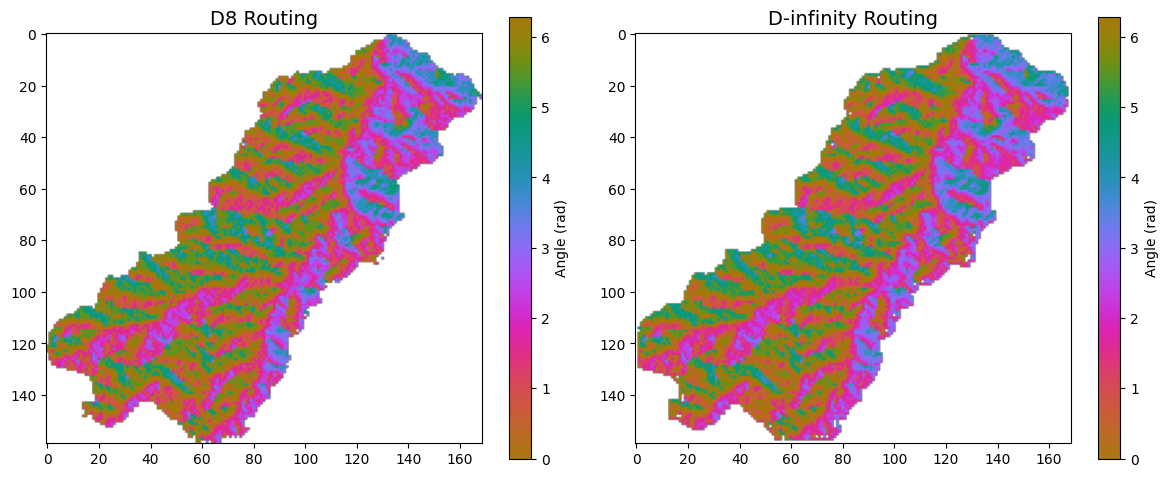

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.8))
im0 = ax[0].imshow(d8_angle, cmap=cmocean.cm.phase, vmin=0, vmax=2*np.pi, zorder=1)
im1 = ax[1].imshow(dinf_angle, cmap=cmocean.cm.phase, vmin=0, vmax=2*np.pi, zorder=1)
ax[0].set_title('D8 Routing', size=14)
ax[1].set_title('D-infinity Routing', size=14)
plt.colorbar(im0, ax=ax[0], label='Angle (rad)')
plt.colorbar(im1, ax=ax[1], label='Angle (rad)')
plt.tight_layout()

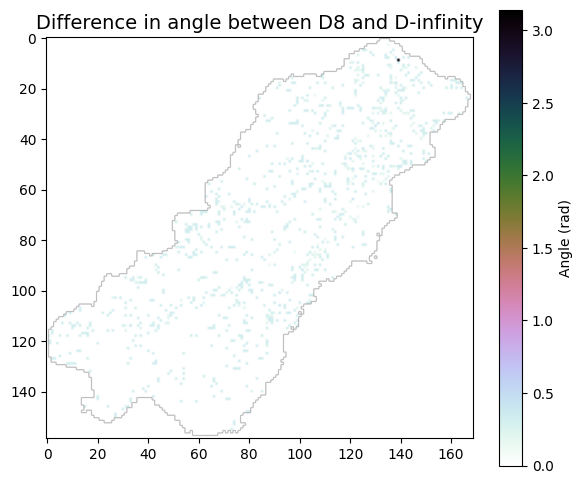

In [12]:
fig, ax = plt.subplots(figsize=(6,5))
diff = np.arctan2(np.sin(dinf_angle - d8_angle), np.cos(dinf_angle - d8_angle))
im0 = plt.imshow(diff, vmin=0, vmax=np.pi, cmap='cubehelix_r', zorder=1)
ax.set_title('Difference in angle between D8 and D-infinity', size=14)
plt.colorbar(im0, ax=ax, label='Angle (rad)')
plt.tight_layout()

# Delineate catchment

In [18]:
# D8 catchment
d8_catch = grid.catchment(x=x, y=y, fdir=d8_fdir, xytype='label', 
                          routing='d8', nodata_out=0)

# D-infinity catchment
dinf_catch = grid.catchment(x=x, y=y, fdir=dinf_fdir, xytype='label', 
                            routing='dinf', nodata_out=0)

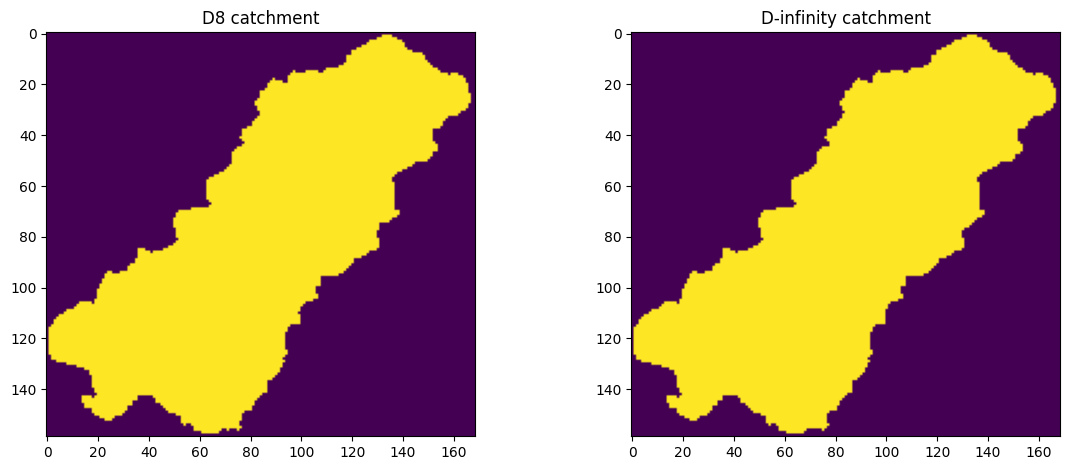

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))

ax[0].imshow(grid.view(d8_catch) > 0, zorder=1)
ax[1].imshow(grid.view(dinf_catch) > 0, zorder=1)

ax[0].set_title('D8 catchment')
ax[1].set_title('D-infinity catchment')
plt.tight_layout()

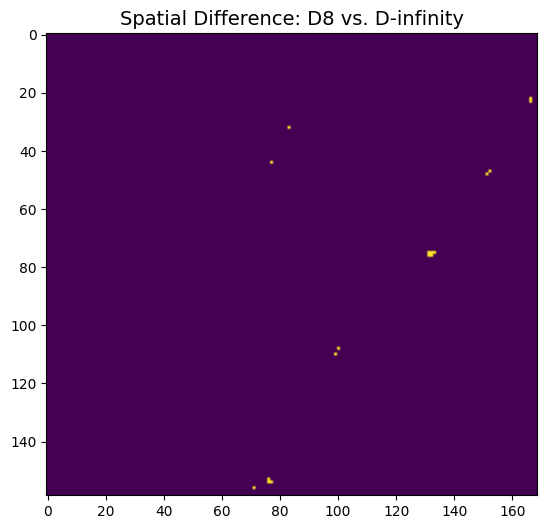

In [32]:
fig, ax = plt.subplots(figsize=(7,6))

# Use > 0 for both since neither uses NaNs anymore
dinf_mask = (grid.view(dinf_catch) > 0)
d8_mask = (grid.view(d8_catch) > 0)

# This will show ONLY the pixels where the two algorithms disagree
ax.imshow(dinf_mask != d8_mask)

ax.set_title('Spatial Difference: D8 vs. D-infinity', size=14)
plt.show()

# Compute accumulation

In [11]:
grid.accumulation('d8_fdir', routing='d8', dirmap=dirmap, out_name='d8_acc')
grid.accumulation('dinf_fdir', routing='dinf', dirmap=dirmap, out_name='dinf_acc')

In [22]:
d8_acc = grid.accumulation(d8_fdir, routing='d8', dirmap=dirmap)
dinf_acc = grid.accumulation(dinf_fdir, routing='dinf')

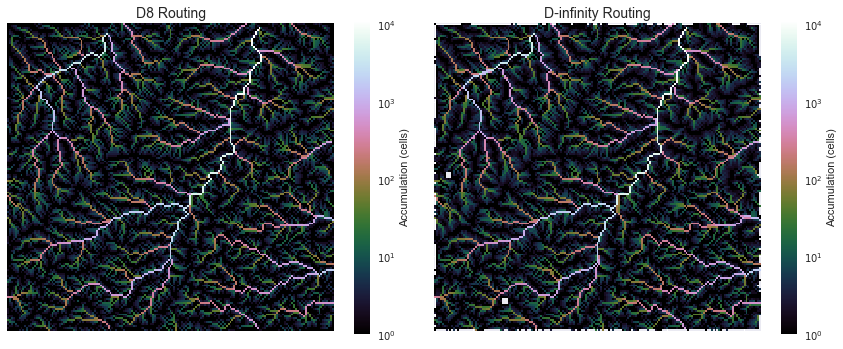

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.8))
im0 = ax[0].imshow(grid.view('d8_acc', apply_mask=False), cmap='cubehelix',
                   norm=colors.LogNorm(vmin=1, vmax=grid.d8_acc.max()), zorder=1)
im1 = ax[1].imshow(grid.view('dinf_acc', apply_mask=False), cmap='cubehelix',
                   norm=colors.LogNorm(vmin=1, vmax=grid.dinf_acc.max()), zorder=1)
ax[0].xaxis.set_ticklabels([])
ax[1].xaxis.set_ticklabels([])
ax[0].yaxis.set_ticklabels([])
ax[1].yaxis.set_ticklabels([])
ax[0].set_title('D8 Routing', size=14)
ax[1].set_title('D-infinity Routing', size=14)
plt.colorbar(im0, ax=ax[0], label='Accumulation (cells)')
plt.colorbar(im1, ax=ax[1], label='Accumulation (cells)')
plt.tight_layout()

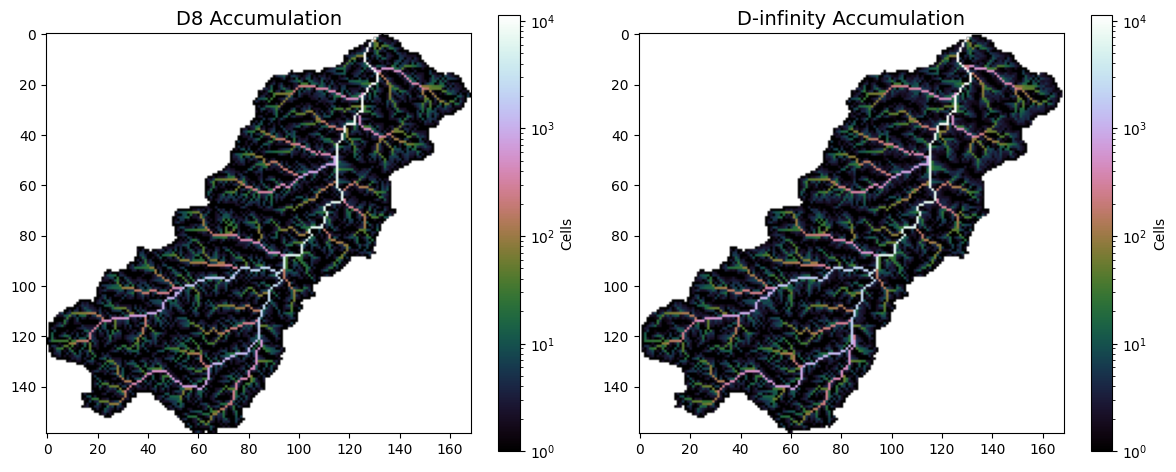

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.8))
im0 = ax[0].imshow(grid.view(d8_acc), cmap='cubehelix',
                   norm=colors.LogNorm(vmin=1, vmax=d8_acc.max()), zorder=1)
im1 = ax[1].imshow(grid.view(dinf_acc), cmap='cubehelix',
                   norm=colors.LogNorm(vmin=1, vmax=dinf_acc.max()), zorder=1)
ax[0].set_title('D8 Accumulation', size=14)
ax[1].set_title('D-infinity Accumulation', size=14)
plt.colorbar(im0, ax=ax[0], label='Cells')
plt.colorbar(im1, ax=ax[1], label='Cells')
plt.tight_layout()

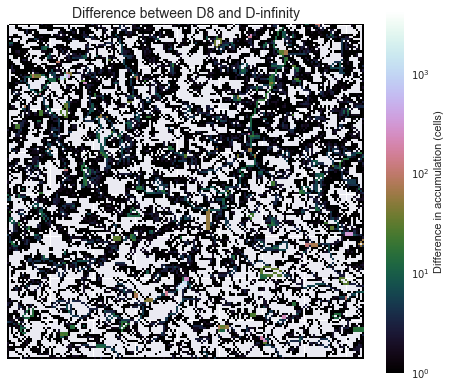

In [13]:
fig, ax = plt.subplots(figsize=(6.5,5.5))

acc_diff = np.abs(grid.view('dinf_acc', apply_mask=False) - grid.view('d8_acc', apply_mask=False))
im0 = ax.imshow(acc_diff, norm=colors.LogNorm(vmin=1, vmax=acc_diff.max()), cmap='cubehelix', zorder=1)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.set_title('Difference between D8 and D-infinity', size=14)
plt.colorbar(im0, label='Difference in accumulation (cells)')
plt.tight_layout()

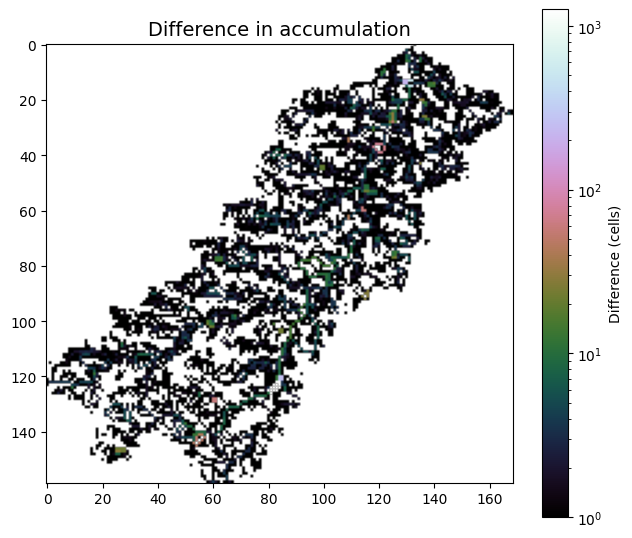

In [24]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
acc_diff = np.abs(grid.view(dinf_acc) - grid.view(d8_acc))
im0 = ax.imshow(acc_diff, norm=colors.LogNorm(vmin=1, vmax=acc_diff.max() + 1), cmap='cubehelix')
ax.set_title('Difference in accumulation', size=14)
plt.colorbar(im0, label='Difference (cells)')
plt.tight_layout()

# Compute flow distance (shortest path)

In [25]:
d8_dist = grid.distance_to_outlet(x=x, y=y, fdir=d8_fdir, routing='d8', 
                                  xytype='label', dirmap=dirmap, nodata_out=np.nan)

dinf_dist = grid.distance_to_outlet(x=x, y=y, fdir=dinf_fdir, routing='dinf', 
                                    xytype='label', dirmap=dirmap, nodata_out=np.nan)

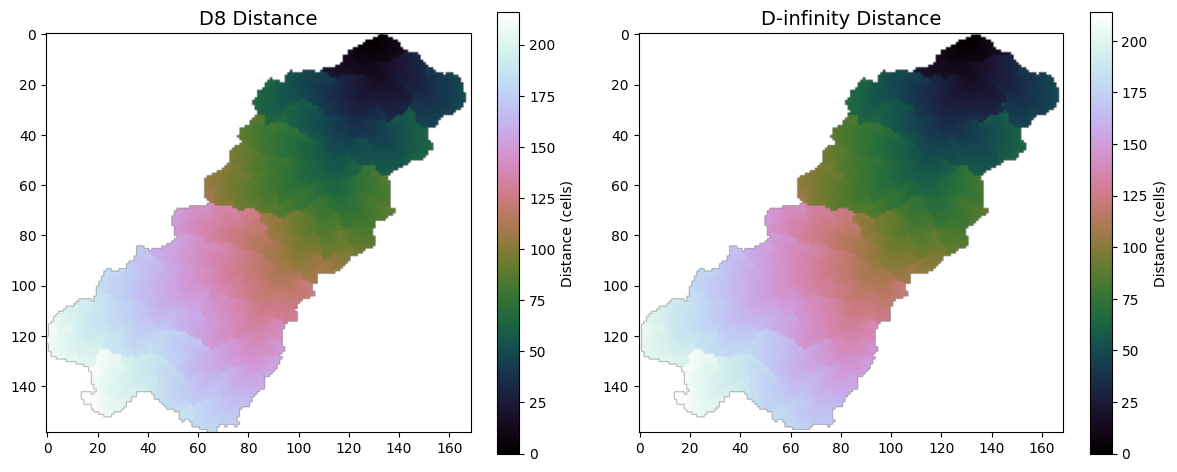

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(12,4.8))
im0 = ax[0].imshow(grid.view(d8_dist), cmap='cubehelix', zorder=1)
im1 = ax[1].imshow(grid.view(dinf_dist), cmap='cubehelix', zorder=1)
ax[0].set_title('D8 Distance', size=14)
ax[1].set_title('D-infinity Distance', size=14)
plt.colorbar(im0, ax=ax[0], label='Distance (cells)')
plt.colorbar(im1, ax=ax[1], label='Distance (cells)')
plt.tight_layout()

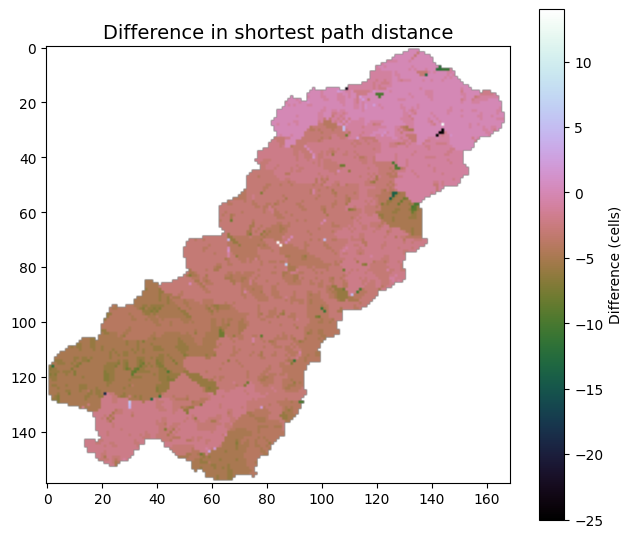

In [27]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
dist_diff = grid.view(dinf_dist) - grid.view(d8_dist)
im0 = ax.imshow(dist_diff, cmap='cubehelix', zorder=1)
ax.set_title('Difference in shortest path distance', size=14)
plt.colorbar(im0, label='Difference (cells)')
plt.tight_layout()